# Satellite-Derived Bathymetry Caballero & Stumpf method

This notebook demonstrates the full SDB workflow following
[Caballero & Stumpf (2019)](https://doi.org/10.1016/j.ecss.2019.106277),
adapted for Google Earth Engine with **gee_acolite**.

The workflow mirrors the approach documented in
[sensingpy](https://aouei.github.io/sensingpy/notebooks/SDB_caballero_stumpf/):

1. Search Sentinel-2 images and apply atmospheric correction (ACOLITE DSF)
2. Build a multi-image composite with `multi_image`
3. Compute the pseudo-SDB ratio (pSDB)
4. Load in-situ bathymetry
5. Fit linear regression: **depth = slope — pSDB + intercept**
6. Apply calibration and the Optical Deep Water filter
7. Validate and visualise

## 1. Environment setup

In [1]:
import sys

sys.path.append(r'D:\acolites\20231023.0')

import ee
import geemap
import folium
import cmocean
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import branca.colormap as bcm
import numpy as np
from scipy import stats
from sensingpy.bathymetry.plot import get_approximate_density

ee.Authenticate()
ee.Initialize()

In [2]:
import acolite

from gee_acolite.utils.search import search_list
from gee_acolite.correction import ACOLITE
from gee_acolite import bathymetry
from gee_acolite.bathymetry import calibrate_sdb, apply_calibration, optical_deep_water_model

SETTINGS_FILE = r'C:\Users\sergi\Documents\repos\gee_acolite\settings.txt'
corrector = ACOLITE(acolite=acolite, settings=SETTINGS_FILE)

# Shared palette -- cmocean.deep (shallow=light, deep=dark), 10 colour stops
# GEE addLayer expects hex without '#'
_n = 10
DEEP_PALETTE = [mcolors.rgb2hex(cmocean.cm.deep(i / (_n - 1)))[1:] for i in range(_n)]

def make_map(layer, vis, name, roi, zoom=11):
    """Folium map with a GEE tile layer and a bottom-right colorbar legend."""
    center = roi.centroid().coordinates().getInfo()  # [lon, lat]
    m = folium.Map(location=[center[1], center[0]], zoom_start=zoom)
    map_id = ee.Image(layer).getMapId(vis)
    folium.TileLayer(
        tiles=map_id['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True,
    ).add_to(m)
    if 'min' in vis and 'max' in vis and 'palette' in vis:
        stops = ', '.join('#' + c for c in vis['palette'])
        legend = (
            '<div style="position:fixed;bottom:20px;right:10px;z-index:1000;'
            'background:white;padding:8px 12px;border-radius:4px;'
            'box-shadow:0 1px 4px rgba(0,0,0,0.3);'
            'font-family:Arial,sans-serif;font-size:13px;">'
            f'<div style="margin-bottom:4px;text-align:center;">{name}</div>'
            '<div style="display:flex;align-items:center;gap:6px;">'
            f'<span>{vis["min"]}</span>'
            f'<div style="width:180px;height:16px;'
            f'background:linear-gradient(to right,{stops});border-radius:2px;"></div>'
            f'<span>{vis["max"]}</span>'
            '</div></div>'
        )
        m.get_root().html.add_child(folium.Element(legend))
    folium.LayerControl().add_to(m)
    return m


## 2. Study area

In [3]:
# Faro / Ria Formosa (Portugal) â€” same area as the original Caballero & Stumpf study
roi = ee.Geometry({
    "type": "Polygon",
    "coordinates": [[
        [-7.729568, 37.042294],
        [-7.890587, 37.042294],
        [-7.890587, 36.937587],
        [-7.729568, 36.937587],
        [-7.729568, 37.042294]
    ]]
})

center = roi.centroid().coordinates().getInfo()
m = folium.Map(location=[center[1], center[0]], zoom_start=11)
folium.GeoJson(roi.getInfo(), name='ROI').add_to(m)
m


## 3. Image search and atmospheric correction (ACOLITE DSF)

In [4]:
# Low-turbidity summer/autumn dates (Sentinel-2 tile T29SPA)
start_dates = [
    '2018-09-19', '2018-09-22', '2018-09-24',
    '2018-10-04', '2018-10-07', '2018-10-17',
    '2018-10-19', '2018-10-22',
]
end_dates = [
    '2018-09-20', '2018-09-23', '2018-09-25',
    '2018-10-05', '2018-10-08', '2018-10-18',
    '2018-10-20', '2018-10-23',
]
TILE = 'T29SPA'
SCALE = 10  # Sentinel-2 native resolution (metres)

sentinel2_l1 = search_list(roi, start_dates, end_dates, tile=TILE)
print(f'Images found: {sentinel2_l1.size().getInfo()}')

# l2w_parameters in settings must include: pSDB_green, pSDB_red, Rrs_B2, Rrs_B3, Rrs_B5
sentinel2_l2w, l2_settings = corrector.correct(sentinel2_l1)
print(f'Corrected images: {sentinel2_l2w.size().getInfo()}')

Images found: 8
Selected model ACOLITE-LUT-202110-MOD2: AOT=0.032, rmsd=4.1756e-04
  Geometry: SZA=37.93°, VZA=6.39°, RAA=48.51°
  Pressure: 1018.85 hPa
Selected model ACOLITE-LUT-202110-MOD2: AOT=0.102, rmsd=1.6409e-04
  Geometry: SZA=38.17°, VZA=9.44°, RAA=126.38°
  Pressure: 1019.79 hPa
Selected model ACOLITE-LUT-202110-MOD1: AOT=0.001, rmsd=5.5159e-04
  Geometry: SZA=39.61°, VZA=6.31°, RAA=51.60°
  Pressure: 1018.82 hPa
Selected model ACOLITE-LUT-202110-MOD1: AOT=0.001, rmsd=2.8123e-03
  Geometry: SZA=43.05°, VZA=6.30°, RAA=54.68°
  Pressure: 1018.17 hPa
Selected model ACOLITE-LUT-202110-MOD2: AOT=0.092, rmsd=1.5946e-05
  Geometry: SZA=43.46°, VZA=9.48°, RAA=122.81°
  Pressure: 1016.25 hPa
Selected model ACOLITE-LUT-202110-MOD1: AOT=0.001, rmsd=1.7919e-03
  Geometry: SZA=46.98°, VZA=9.49°, RAA=120.81°
  Pressure: 1016.72 hPa
Selected model ACOLITE-LUT-202110-MOD2: AOT=0.001, rmsd=2.8795e-03
  Geometry: SZA=48.22°, VZA=6.31°, RAA=56.80°
  Pressure: 1011.04 hPa
Selected model ACOLITE

## 4. Multi-image composite (clearest pixel selection)

Following Caballero & Stumpf (2019), images are combined into a single composite
by selecting the pixel with the **highest pSDB_green** value the clearest
(least turbid) observation at each location.

In [5]:
image = bathymetry.multi_image(sentinel2_l2w, band='pSDB_green').clip(roi)

make_map(
    image.select('pSDB_green'),
    {'min': 0.9, 'max': 1.2, 'palette': DEEP_PALETTE},
    'pSDB_green',
    roi
)

## 5. In-situ bathymetry

Reference depth raster depths are **positive** values in metres.

In [6]:
insitu = ee.Image('projects/ee-sergiohercar1/assets/InSituBathymetry/2018_10m').rename(['depth'])

make_map(
    insitu,
    {'min': 0, 'max': 20, 'palette': DEEP_PALETTE},
    'In-situ depth (m)',
    roi
)

## 6. Calibration

### 6.1 Linear regression

All valid pixels where `0 < depth < max_depth` **and** `pSDB_green` is not masked
are used to fit:

$$\text{depth} = m \cdot \text{pSDB}_{\text{green}} + b$$

In [7]:
MAX_DEPTH = 10  # metres

cal_result = calibrate_sdb(
    psdb_image=image.select('pSDB_green'),
    insitu_bathymetry=insitu,
    region=roi,
    max_depth=MAX_DEPTH,
    num_sample_points=800,
    seed=42,
    scale=SCALE
)

slope = cal_result['slope']
intercept = cal_result['intercept']

print('=== Calibration results ===')
print(f'  Pixels used  : {cal_result["num_pixels"]:,}')
print(f'  Slope        : {slope:.4f}')
print(f'  Intercept    : {intercept:.4f}')
print(f'  Correlation  : {cal_result["correlation"]:.4f}')
print(f'  Equation     : depth = {slope:.4f} Ã— pSDB_green + ({intercept:.4f})')

=== Calibration results ===
  Pixels used  : 97,217
  Slope        : 74.1771
  Intercept    : -71.0190
  Correlation  : 0.9727
  Equation     : depth = 74.1771 Ã— pSDB_green + (-71.0190)


### 6.2 Calibration scatter plot

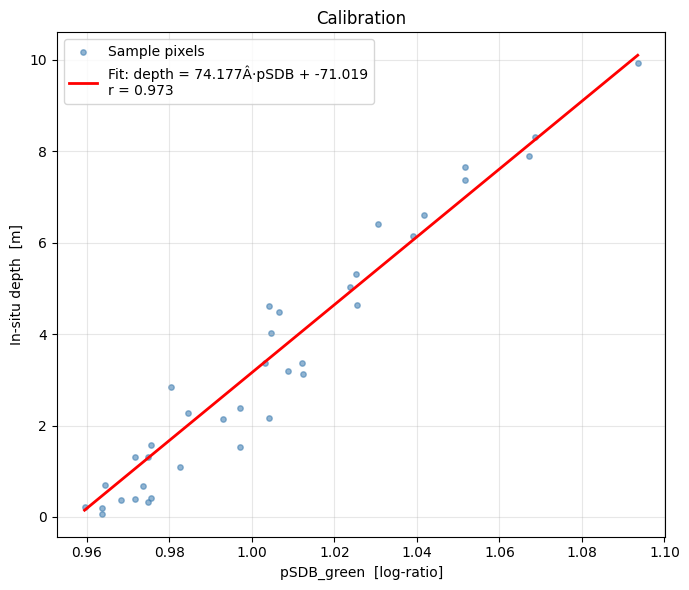

In [8]:
df_cal = geemap.ee_to_df(cal_result['sample_fc'])
df_cal = df_cal[['pSDB_green', 'depth']].dropna()

x_line = np.linspace(df_cal['pSDB_green'].min(), df_cal['pSDB_green'].max(), 100)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df_cal['pSDB_green'], df_cal['depth'],
           s=15, alpha=0.6, color='steelblue', label='Sample pixels')
ax.plot(x_line, y_line, 'r-', lw=2,
        label=f'Fit: depth = {slope:.3f}Â·pSDB + {intercept:.3f}\n'
              f'r = {cal_result["correlation"]:.3f}')
ax.set_xlabel('pSDB_green  [log-ratio]')
ax.set_ylabel('In-situ depth  [m]')
ax.set_title('Calibration')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Apply calibration

In [9]:
sdb_green = apply_calibration(
    psdb_image=image.select('pSDB_green'),
    slope=slope,
    intercept=intercept,
    output_name='SDB_green'
)
image = image.addBands(sdb_green)

make_map(
    sdb_green.clip(roi),
    {'min': 0, 'max': 15, 'palette': DEEP_PALETTE},
    'SDB_green',
    roi
)

## 8. Optical Deep Water filter

The ODW model (Caballero & Stumpf 2019) masks pixels in two situations:

* **Clear water** â€” Rrs_blue or Rrs_green â‰¤ 0.003 (no retrievable signal)
* **Turbid water** â€” depth estimate exceeds the turbidity-limited maximum:
  $Y_{\max} = -0.251 \ln(R_{rs}^{\text{NIR}}) + 0.8$

In [10]:
sdb_odw = optical_deep_water_model(
    model=image.select('SDB_green'),
    blue=image.select('Rrs_B2'),
    green=image.select('Rrs_B3'),
    vnir=image.select('Rrs_B5'),
).rename('SDB_green_ODW')

image = image.addBands(sdb_odw)

make_map(
    sdb_odw.clip(roi),
    {'min': 0, 'max': 15, 'palette': DEEP_PALETTE},
    'SDB_green (ODW filtered)',
    roi
)

## 9. Validation

SDB vs in-situ comparison across all available depth pixels.

In [11]:
# Imagen combinada: solo pÃ­xeles donde SDB_green_ODW e insitu tienen datos simultÃ¡neamente
validation_image = sdb_odw.addBands(insitu).updateMask(
    sdb_odw.mask().And(insitu.mask()).And(insitu.gt(0))
)

# numPixels=1e6 â†’ GEE devuelve todos los pÃ­xeles disponibles si hay menos de ese lÃ­mite
val_sample = validation_image.sample(
    region=roi,
    scale=SCALE,
    numPixels=int(1e6),
    tileScale=4,
    seed=99,
    geometries=False
)

df_val = geemap.ee_to_df(val_sample)[['SDB_green_ODW', 'depth']].dropna()
print(f'Validation pixels: {len(df_val)}')

Validation pixels: 38199


In [12]:
sdb_pred = df_val['SDB_green_ODW'].values
sdb_true = df_val['depth'].values

mae  = np.mean(np.abs(sdb_pred - sdb_true))
rmse = np.sqrt(np.mean((sdb_pred - sdb_true) ** 2))
bias = np.mean(sdb_pred - sdb_true)
r, _ = stats.pearsonr(sdb_true, sdb_pred)

print('=== Validation metrics (SDB_green ODW) ===')
print(f'  n    = {len(df_val)}')
print(f'  MAE  = {mae:.3f} m')
print(f'  RMSE = {rmse:.3f} m')
print(f'  Bias = {bias:.3f} m')
print(f'  r    = {r:.3f}')

=== Validation metrics (SDB_green ODW) ===
  n    = 38199
  MAE  = 0.582 m
  RMSE = 0.745 m
  Bias = -0.010 m
  r    = 0.968


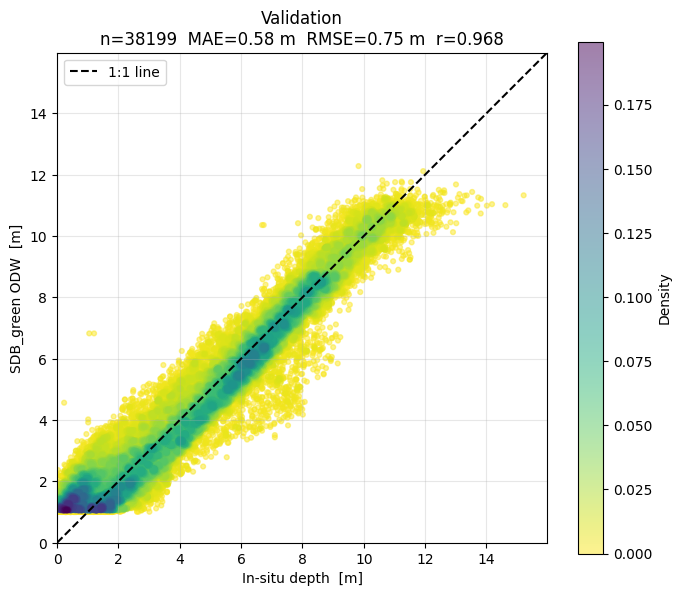

In [13]:
lim = [0, max(sdb_true.max(), sdb_pred.max()) * 1.05]
x, y, z, norm = get_approximate_density(sdb_true, sdb_pred, bins = 100)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(x, y, c = z, norm=norm, s=12, alpha=0.5, cmap='viridis_r')
ax.plot(lim, lim, 'k--', lw=1.5, label='1:1 line')
plt.colorbar(sc, ax=ax, label='Density')
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel('In-situ depth  [m]')
ax.set_ylabel('SDB_green ODW  [m]')
ax.set_title(
    f'Validation\n'
    f'n={len(df_val)}  MAE={mae:.2f} m  RMSE={rmse:.2f} m  r={r:.3f}'
)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 10. Error distribution

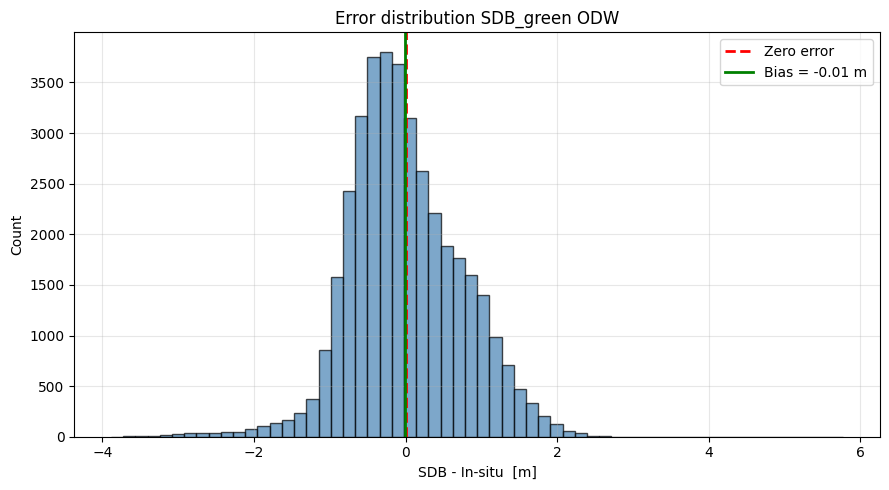

In [16]:
errors = sdb_pred - sdb_true

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(errors, bins=60, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(0, color='red', ls='--', lw=2, label='Zero error')
ax.axvline(bias, color='green', lw=2, label=f'Bias = {bias:.2f} m')
ax.set_xlabel('SDB - In-situ  [m]')
ax.set_ylabel('Count')
ax.set_title('Error distribution SDB_green ODW')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Final map

In [15]:
make_map(
    sdb_odw.clip(roi),
    {'min': 0, 'max': 15, 'palette': DEEP_PALETTE},
    'SDB_green ODW (final)',
    roi
)